# **Principal Components Analysis (PCA) y Sistemas de Recomendación.**

Tutorial para la realización de métodos del Aprendizaje No Supervisado:
* Principal Components Analysis (PCA).

* Sistemas de Recomendación.

**Hecho por: Estefania Nájera de la Rosa - estefania.najera@udem.edu a 13 de abril del 2026.**

# Principal Components Analysis (PCA).

Este método sirve para:
* Proyectar las características en componentes para tomar las principales según en % a cumplir.

* Reduce la dimensionaidad sin perder demasiada información.

Y es el que comenzaremos por desarrollar en el siguiente tutorial.

Tenemos que importar las librerías necesarias, estas siendo:
* **pandas** para el procesamiento de los datos.

* **numpy** para cálculos matemáticos.

* **matplotlib.pyplot** y **seaborn** para gráficas

En esta ocasión, estaremos trabajando con un dataset de cáncer de mama otorgado por la siguiente librería:
* **sklearn.datasets** con la declaración del dataset que es **load_breast_cancer**.

In [41]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargamos el dataset una vez que fue declarado.

In [42]:
# Cargar el dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target, name='target')

**Características del Dataset 'Breast Cancer'.**

Vamos a explorar las características principales del dataset, como el tamaño, el tipo de datos, las clases y la presencia de valores nulos.

In [43]:
print("### Dimensiones del dataset ###")
print(f"Dimensiones de las características (X): {X.shape}")
print(f"Dimensiones de la variable objetivo (y): {y.shape}\n")

print("### Tipos de datos de las características ###")
print(X.info())
print(f"\nTipos de datos de la variable objetivo (y): {y.dtype}\n")

print("### Clases en la variable objetivo ###")
print(f"Nombres de las clases: {breast_cancer.target_names}")
print("Distribución de las clases:")
print(y.value_counts())
print("\n")

print("### Verificación de valores nulos ###")
missing_values_X = X.isnull().sum()
missing_values_y = y.isnull().sum()

if missing_values_X.sum() == 0 and missing_values_y == 0:
    print("No hay valores nulos en el dataset.")
else:
    print("Valores nulos en X:\n", missing_values_X[missing_values_X > 0])
    print("Valores nulos en y:\n", missing_values_y)

### Dimensiones del dataset ###
Dimensiones de las características (X): (569, 30)
Dimensiones de la variable objetivo (y): (569,)

### Tipos de datos de las características ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture err

Aquí podemos observar que todos nuestros datos son de tipo flotante, por lo que no hay que hacer ajustes de variables categóricas a numéricas.

**Análisis Univariable: Gráficas de Densidad.**

Vamos a visualizar la distribución de algunas de las características más importantes utilizando gráficas de densidad, separando por la clase (maligno vs. benigno) para observar posibles diferencias.

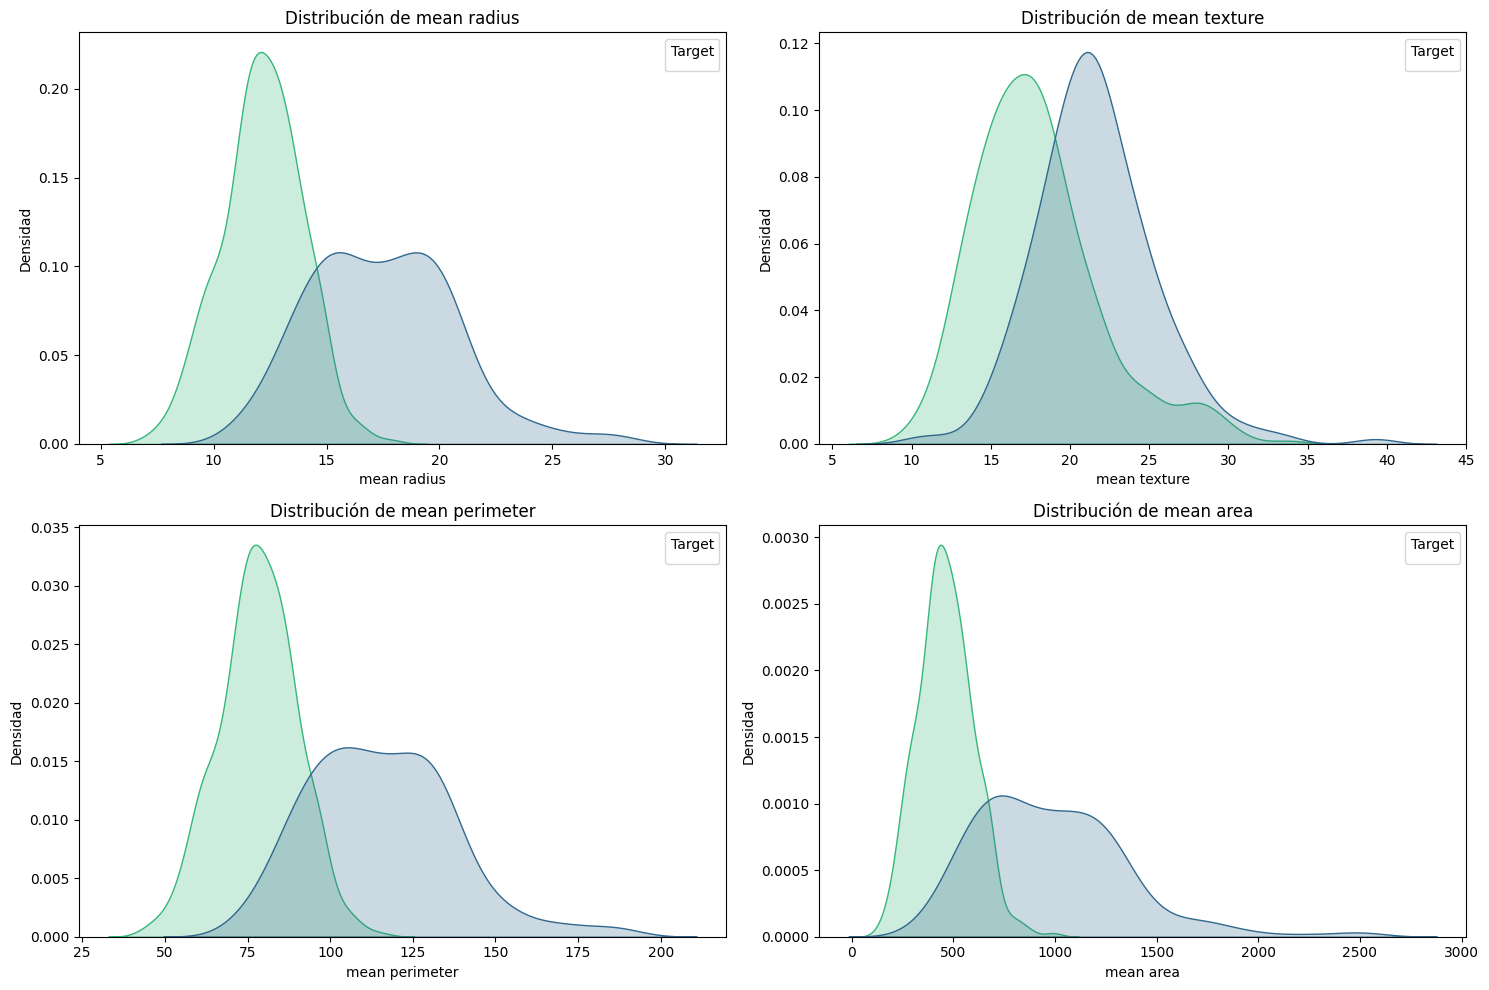

In [44]:
selected_features_uni = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features_uni):
    plt.subplot(2, 2, i + 1)
    # Let seaborn handle the legend generation directly
    sns.kdeplot(data=X, x=feature, hue=y, fill=True, common_norm=False, palette='viridis')
    plt.title(f'Distribución de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Densidad')
    # Customize legend labels after seaborn has created them
    current_handles, current_labels = plt.gca().get_legend_handles_labels()
    new_labels = [breast_cancer.target_names[int(float(label))] for label in current_labels]
    plt.gca().legend(current_handles, new_labels, title='Target')

plt.tight_layout()
plt.show()

**Análisis Bivariable: Gráficas de Dispersión.**

Ahora, exploremos las relaciones entre pares de características utilizando gráficas de dispersión, nuevamente diferenciando por la clase para identificar patrones de separación.

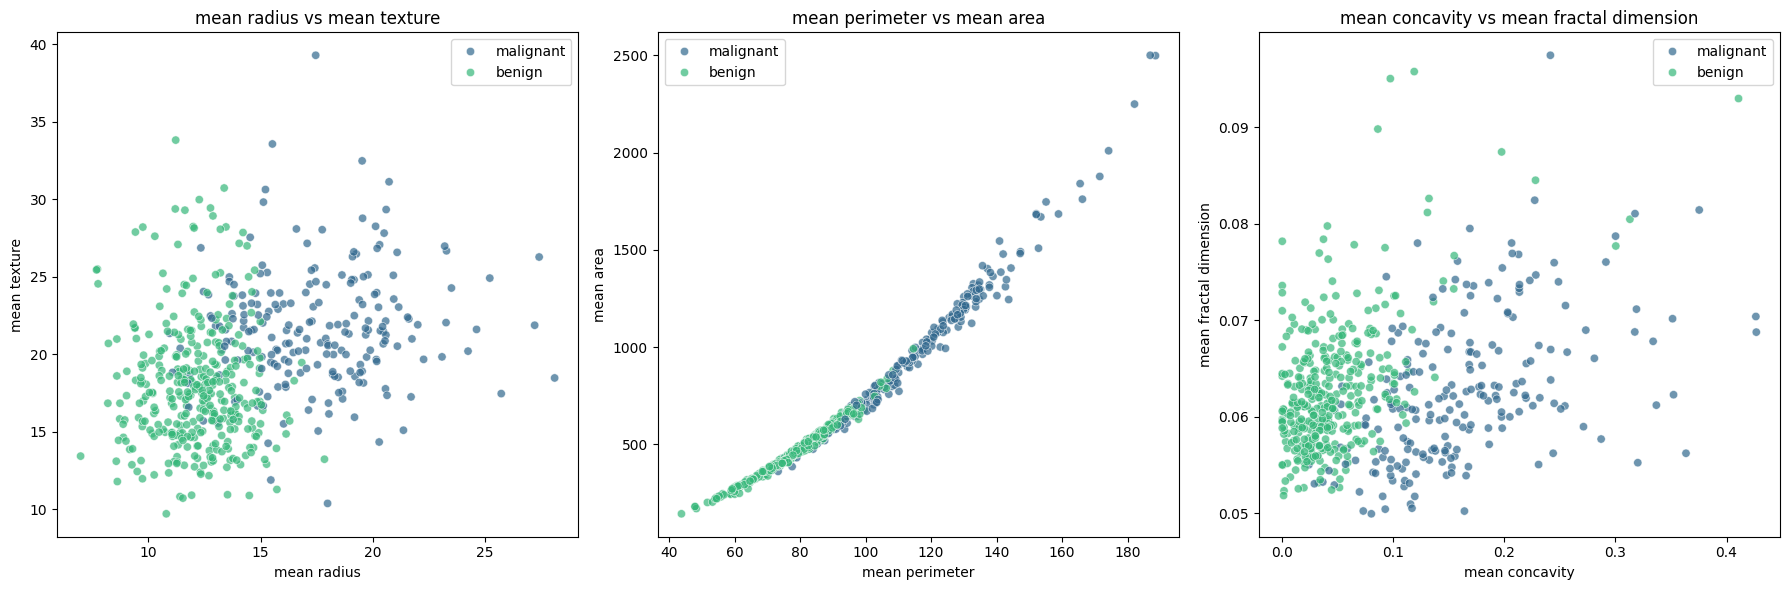

In [45]:
selected_features_bi = [('mean radius', 'mean texture'), ('mean perimeter', 'mean area'), ('mean concavity', 'mean fractal dimension')]

plt.figure(figsize=(18, 6))
for i, (feature1, feature2) in enumerate(selected_features_bi):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X[feature1], y=X[feature2], hue=y, palette='viridis', alpha=0.7)
    plt.title(f'{feature1} vs {feature2}')
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.gca().legend(handles=handles, labels=[breast_cancer.target_names[int(float(label))] for label in labels])

plt.tight_layout()
plt.show()

**Preparación de Datos: División y Estandarización.**

Dividiremos el dataset en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo. Luego, estandarizaremos las características para asegurar que todas contribuyan de manera equitativa al modelo.

Importamos **sklearn.model_selection** con **train_test_split** para dividir, seguido de **sklearn.preprocessing** con **StandardScaler** para estandarizar los datos.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (398, 30)
Dimensiones de X_test: (171, 30)
Dimensiones de y_train: (398,)
Dimensiones de y_test: (171,)


In [47]:
# Estandarizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos estandarizados correctamente.")
# Mostrar las primeras 5 filas de los datos de entrenamiento estandarizados
print("\nPrimeras 5 filas de X_train_scaled (estandarizado):\n")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Datos estandarizados correctamente.

Primeras 5 filas de X_train_scaled (estandarizado):

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0    -0.709821     -0.258417       -0.637396  -0.711996         1.628430   
1    -0.830331      2.231127       -0.874980  -0.779081        -1.597569   
2    -1.011097     -0.227270       -1.035172  -0.911780        -1.077779   
3    -0.382721     -0.111581       -0.408966  -0.453660         0.072810   
4    -0.804508     -1.401961       -0.810071  -0.773196         0.191319   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          0.847289        0.166501             0.196420       0.542716   
1         -1.267717       -1.086471            -1.243232      -2.658543   
2         -1.098096       -0.841650            -0.955767       2.023790   
3         -0.443255       -0.756276            -0.782409      -0.163916   
4         -0.507801       -0.685397            -0.530392      -0.128228   

  

**Modelado: Regresión Logística y Evaluación.**

Ahora vamos a entrenar un modelo de Regresión Logística con los datos estandarizados, y luego evaluaremos su rendimiento utilizando métricas clave como Accuracy, F1-Score y AUC.

Es importante mencionar que para la elaboración de este modelo de clasificación, necesitamos importar su librería:
* **sklearn.linear_model** con la declaración del algoritmo que es **LogisticRegression**.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Inicializar y entrenar el modelo de Regresión Logística
# Se usa random_state para reproducibilidad y solver='liblinear' es bueno para datasets pequeños y binarios
model = LogisticRegression(random_state=42, solver='liblinear') # Regularización con LogisticRegression de L2
model.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


In [49]:
# Realizar predicciones sobre el conjunto de prueba estandarizado
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilidades para la clase positiva

print("Predicciones realizadas.")

Predicciones realizadas.


In [50]:
# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"### Métricas del Modelo de Regresión Logística ###")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")

print("\n### Matriz de Confusión ###")
print(confusion_matrix(y_test, y_pred))

print("\n### Reporte de Clasificación ###")
print(classification_report(y_test, y_pred))

### Métricas del Modelo de Regresión Logística ###
Accuracy: 0.9883
F1-Score: 0.9907
AUC: 0.9981

### Matriz de Confusión ###
[[ 63   1]
 [  1 106]]

### Reporte de Clasificación ###
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



Los resultados del modelo nos indican lo siguiente:

**Matriz de Confusión:**
* 169 aciertos.

* 2 errores.

**171 datos en total.**

**Reporte de Clasificación:**
* Con 64 datos de la clase 0, se obtiene:
    * 98% de positivos encontrados (recall).
    * 98% fueron clasificados correctamente (precision).
    * 98% es el promedio ponderado de las clases (f1-score).

* Con 107 datos de la clase 1, se obtiene:
    * 99% de positivos encontrados.
    * 99% fueron clasificados correctamente.
    * 99% es el promedio ponderado de las clases (f1-score).

El modelo tiene un accuracy de 99%.

**Visualización de la Curva ROC (Receiver Operating Characteristic).**

Vamos a graficar la curva ROC para el modelo de Regresión Logística original para tener una representación visual de su rendimiento.

Importamos **sklearn.metrics** con sus declaraciones de **roc_curve** y **auc**.

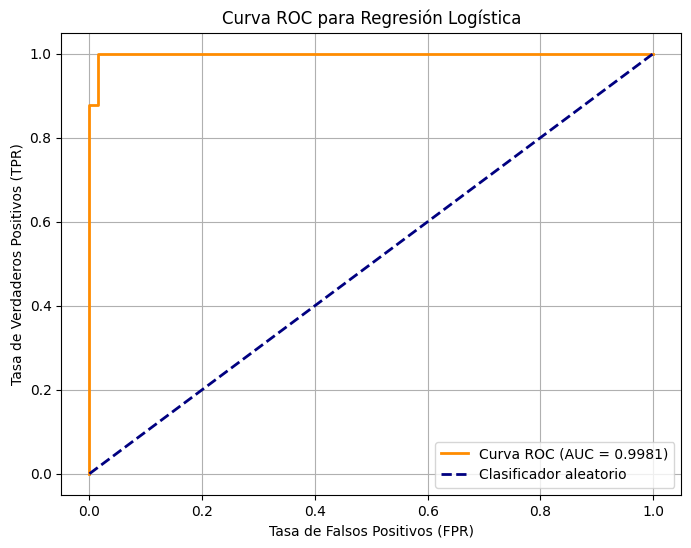

In [51]:
from sklearn.metrics import roc_curve, auc

# Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Análisis de Componentes Principales (PCA).**

Ahora aplicaremos PCA a nuestros datos estandarizados para reducir la dimensionalidad y entender las principales fuentes de variabilidad. Analizaremos la varianza explicada por cada componente principal y visualizaremos los resultados.

Importamos **sklearn.decomposition** con la declaración del método de **PCA**.

In [52]:
from sklearn.decomposition import PCA

# Inicializar PCA y ajustarlo a los datos de entrenamiento escalados
pca = PCA(n_components=None) # n_components=None para mantener todas las componentes y luego decidir
pca.fit(X_train_scaled)

# Varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_

# Suma acumulada de la varianza explicada
cum_explained_variance = np.cumsum(explained_variance_ratio)

print("Varianza explicada por cada componente principal:\n", explained_variance_ratio[:5]) # Mostrar las primeras 5
print("\nVarianza acumulada explicada:\n", cum_explained_variance[:5]) # Mostrar las primeras 5

Varianza explicada por cada componente principal:
 [0.45156229 0.19628669 0.08897898 0.06596846 0.05540815]

Varianza acumulada explicada:
 [0.45156229 0.64784898 0.73682795 0.80279641 0.85820456]


**Visualización de la Varianza Explicada.**

Grafiquemos la varianza explicada acumulada para determinar cuántos componentes principales retener.

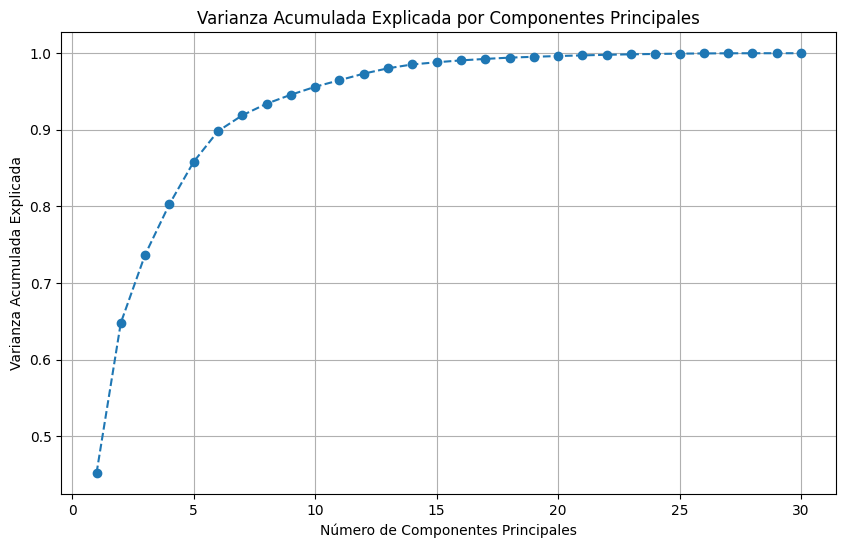

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

Vale la pena mencionar que aquí es donde podemos delimitar cuántos componentes necesitamos para explicar cierto porcentaje que se establezca.

Por ejemplo, si queremos explicar hasta un 80%, podemos hacerlo con alrededor de 4 componentes, mientras que el explicar un 60%-70% se puede hacer con 2 o 3 componentes. Esto se va a profundizar más adelante con exactitud.

**Varianza Explicada por Componente Principal.**

Vamos a visualizar la varianza explicada individualmente por cada componente principal para identificar un "codo" que sugiera un número óptimo de componentes.

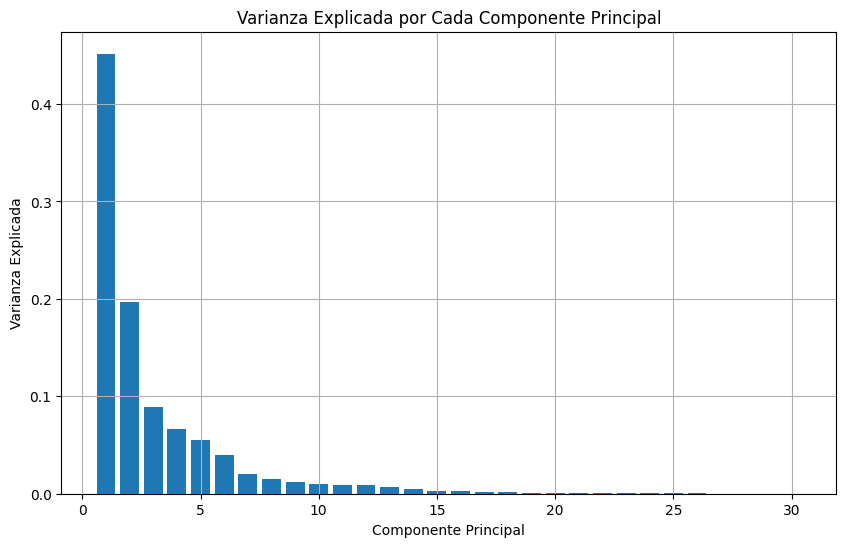

In [54]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.title('Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.grid(True)
plt.show()

**Identificación de Componentes para Varianza Acumulada.**

Basándonos en la gráfica de varianza acumulada, podemos determinar el número de componentes necesarios para explicar un porcentaje deseado de la varianza total de los datos. Esto nos ayudará a elegir el **'n_components'** para el entrenamiento de nuestros modelos.

Aquí identificamos los componentes para el 60%, 70% y 80% de la varianza explicada:

In [55]:
def find_n_components(cumulative_variance, target_variance):
    for i, var in enumerate(cumulative_variance):
        if var >= target_variance:
            return i + 1
    return len(cumulative_variance)

n_components_60 = find_n_components(cum_explained_variance, 0.60)
n_components_70 = find_n_components(cum_explained_variance, 0.70)
n_components_80 = find_n_components(cum_explained_variance, 0.80)
n_components_90 = find_n_components(cum_explained_variance, 0.90)

print(f"Para explicar el 60% de la varianza, se necesitan {n_components_60} componentes.")
print(f"Para explicar el 70% de la varianza, se necesitan {n_components_70} componentes.")
print(f"Para explicar el 80% de la varianza, se necesitan {n_components_80} componentes.")
print(f"Para explicar el 90% de la varianza, se necesitan {n_components_90} componentes.")

# Definir una lista de n_components a probar, incluyendo el modelo original sin PCA y con PCA completo si aplica
components_to_test = [n_components_60, n_components_70, n_components_80, n_components_90]
components_to_test = sorted(list(set(components_to_test))) # Eliminar duplicados y ordenar

Para explicar el 60% de la varianza, se necesitan 2 componentes.
Para explicar el 70% de la varianza, se necesitan 3 componentes.
Para explicar el 80% de la varianza, se necesitan 4 componentes.
Para explicar el 90% de la varianza, se necesitan 7 componentes.


**Modelado y Comparación con Diferentes Componentes PCA.**

Ahora, vamos a entrenar y evaluar modelos de Regresión Logística utilizando el número de componentes PCA identificados para diferentes niveles de varianza explicada. Compararemos los resultados con el modelo original (sin PCA) para entender el impacto de la reducción de dimensionalidad.

In [56]:
results = {}

# Función para entrenar y evaluar el modelo con un número dado de componentes
def train_and_evaluate_pca_model(n_comp):
    if n_comp == 0: # Caso para el modelo sin PCA (usando todos los componentes originales o un marcador)
        # Se usará el modelo previamente entrenado sin PCA
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        pca_temp = PCA(n_components=n_comp, random_state=42) # random_state para reproducibilidad
        X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
        X_test_pca_temp = pca_temp.transform(X_test_scaled)

        model_pca = LogisticRegression(random_state=42, solver='liblinear')
        model_pca.fit(X_train_pca_temp, y_train)

        y_pred = model_pca.predict(X_test_pca_temp)
        y_pred_proba = model_pca.predict_proba(X_test_pca_temp)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    return {'Accuracy': accuracy, 'F1-Score': f1, 'AUC': roc_auc}

# Evaluar el modelo original (sin PCA, ya entrenado)
results['Original (No PCA)'] = train_and_evaluate_pca_model(0) # Usar 0 como marcador para el modelo original

# Evaluar modelos con diferentes números de componentes PCA
for n_comp in components_to_test:
    print(f"Entrenando modelo con {n_comp} componentes PCA...")
    results[f'{n_comp} Components (PCA)'] = train_and_evaluate_pca_model(n_comp)

# Convertir resultados a DataFrame para una mejor visualización
results_df = pd.DataFrame.from_dict(results, orient='index')

print("\n### Comparación de Rendimiento de Modelos ###")
display(results_df.sort_values(by='F1-Score', ascending=False))

Entrenando modelo con 2 componentes PCA...
Entrenando modelo con 3 componentes PCA...
Entrenando modelo con 4 componentes PCA...
Entrenando modelo con 7 componentes PCA...

### Comparación de Rendimiento de Modelos ###


,Accuracy,F1-Score,AUC
Original (No PCA),0.988304,0.990654,0.998102
4 Components (PCA),0.959064,0.968037,0.995765
7 Components (PCA),0.959064,0.966825,0.995911
2 Components (PCA),0.953216,0.962617,0.992261
3 Components (PCA),0.912281,0.929577,0.988172


**Heatmaps de Correlación: Antes y Después de PCA.**

Vamos a visualizar la matriz de correlación de las características originales y luego cómo se comportan las correlaciones de las componentes principales. Esto nos ayudará a entender cómo PCA descorrelaciona las variables.

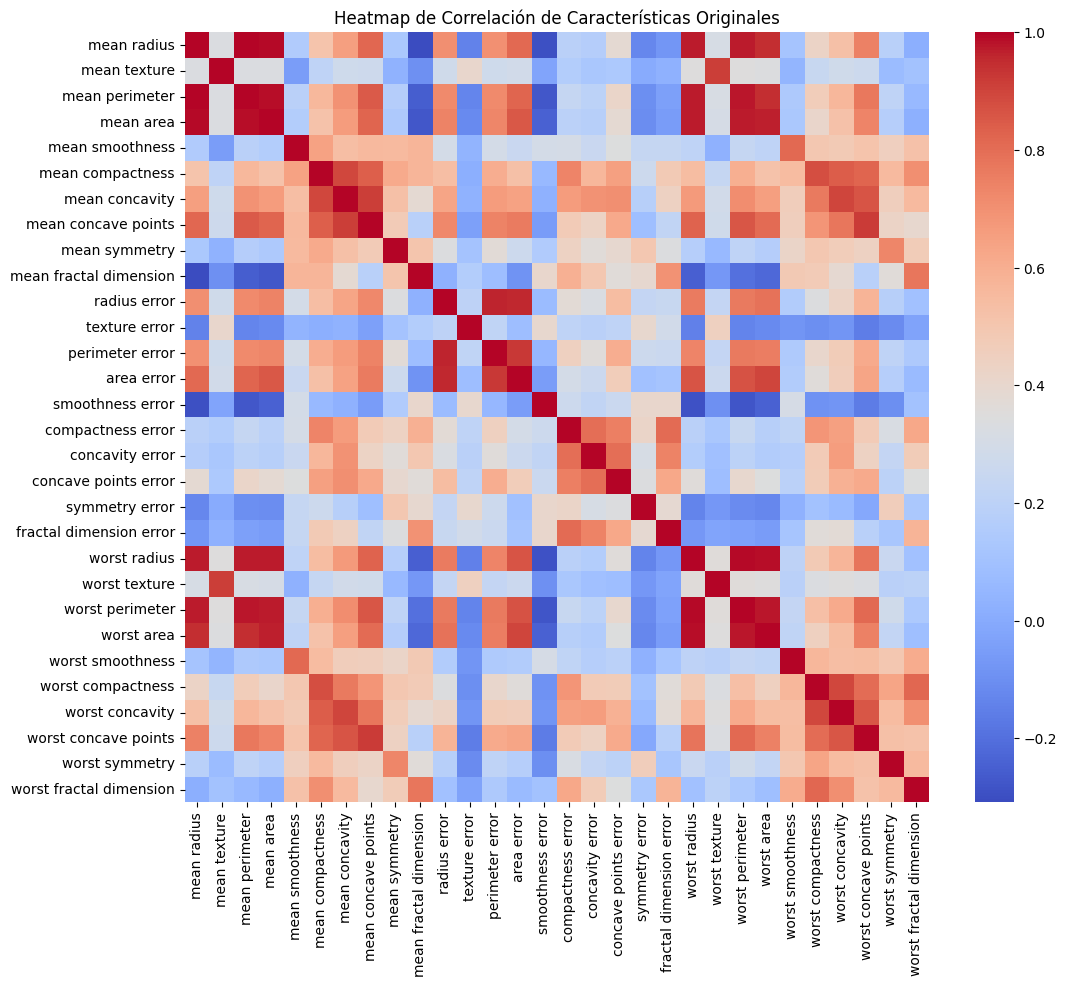

In [57]:
# Correlación de las características originales
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap de Correlación de Características Originales')
plt.show()

Seguimos ahora en transformar los datos de entrenamiento y prueba usando PCA con el número de componentes deseado

Por ejemplo, podemos seleccionar componentes que expliquen el 95% de la varianza (o el que se decida del gráfico)

Para este ejemplo en concreto, tomaremos los 10 primeros componentes por simplificar, pero se podría ajustar.

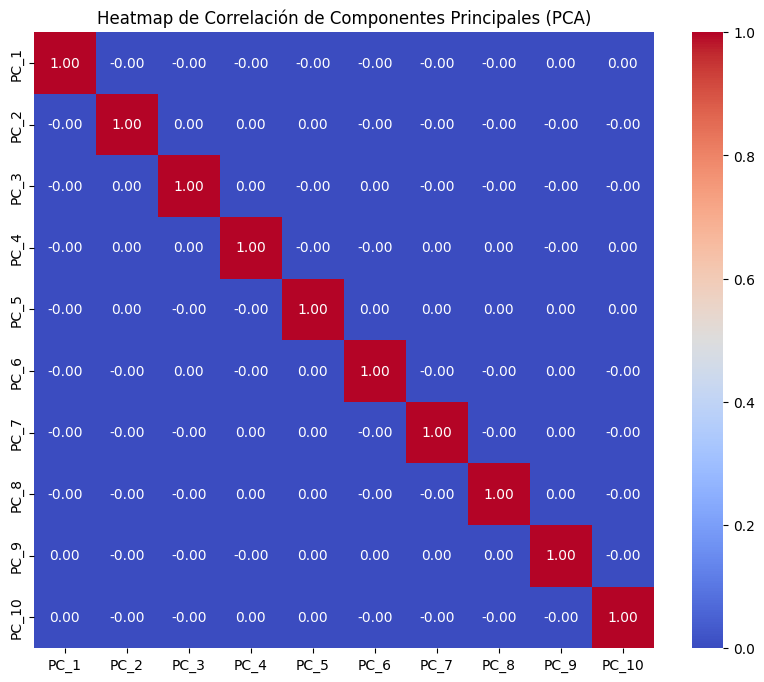

In [58]:
# Vamos a re-inicializar PCA para un número fijo de componentes basado en la varianza explicada
n_components_to_retain = 10 # Se puede ajustar según el gráfico de varianza acumulada
pca_final = PCA(n_components=n_components_to_retain)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# Crear un DataFrame para las componentes principales transformadas (para el heatmap de correlación)
pca_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(n_components_to_retain)])

# Correlación de las Componentes Principales
plt.figure(figsize=(10, 8))
sns.heatmap(pca_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Correlación de Componentes Principales (PCA)')
plt.show()

**Visualización de los Datos: Antes y Después de PCA.**

Para entender mejor cómo PCA transforma los datos, vamos a visualizar las matrices de las características originales (escaladas) y de las componentes principales resultantes. Esto nos permitirá observar directamente la reorganización de la información.

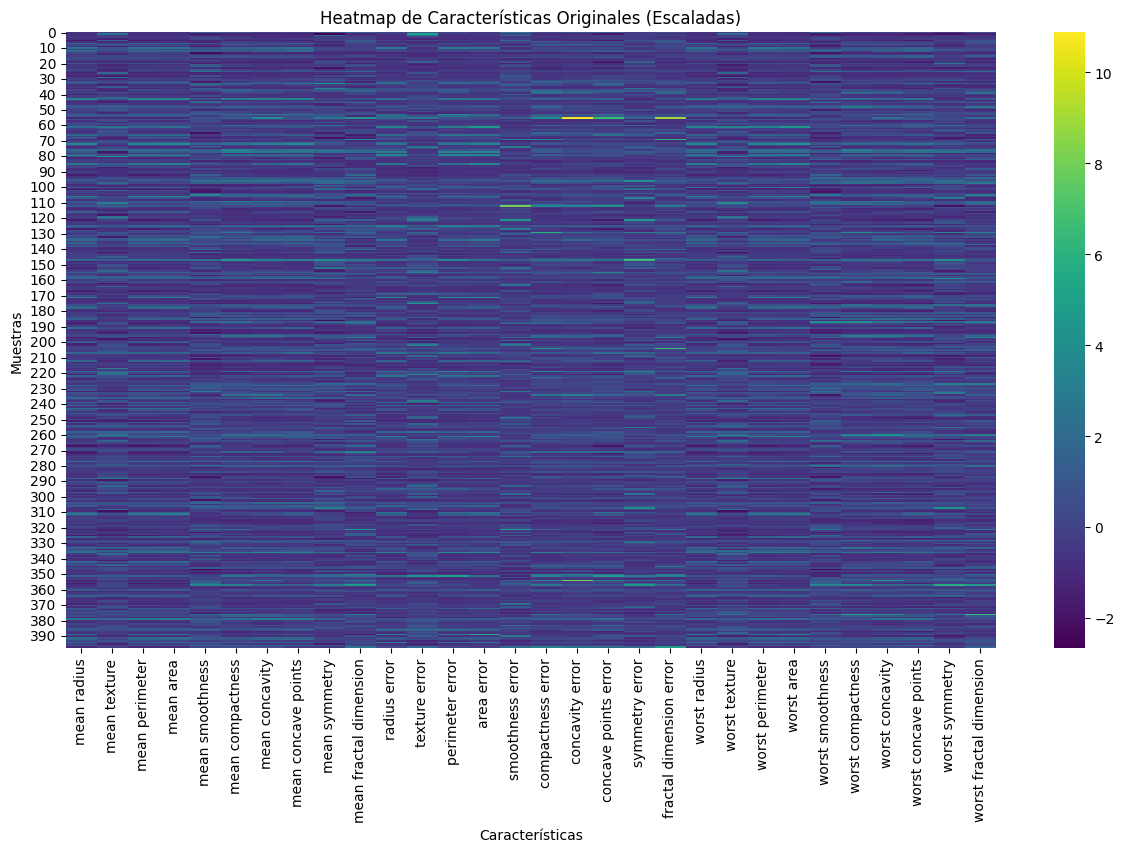

In [59]:
# Visualización de las características originales (escaladas)
plt.figure(figsize=(15, 8))
sns.heatmap(pd.DataFrame(X_train_scaled, columns=X.columns), cmap='viridis', cbar=True)
plt.title('Heatmap de Características Originales (Escaladas)')
plt.xlabel('Características')
plt.ylabel('Muestras')
plt.show()

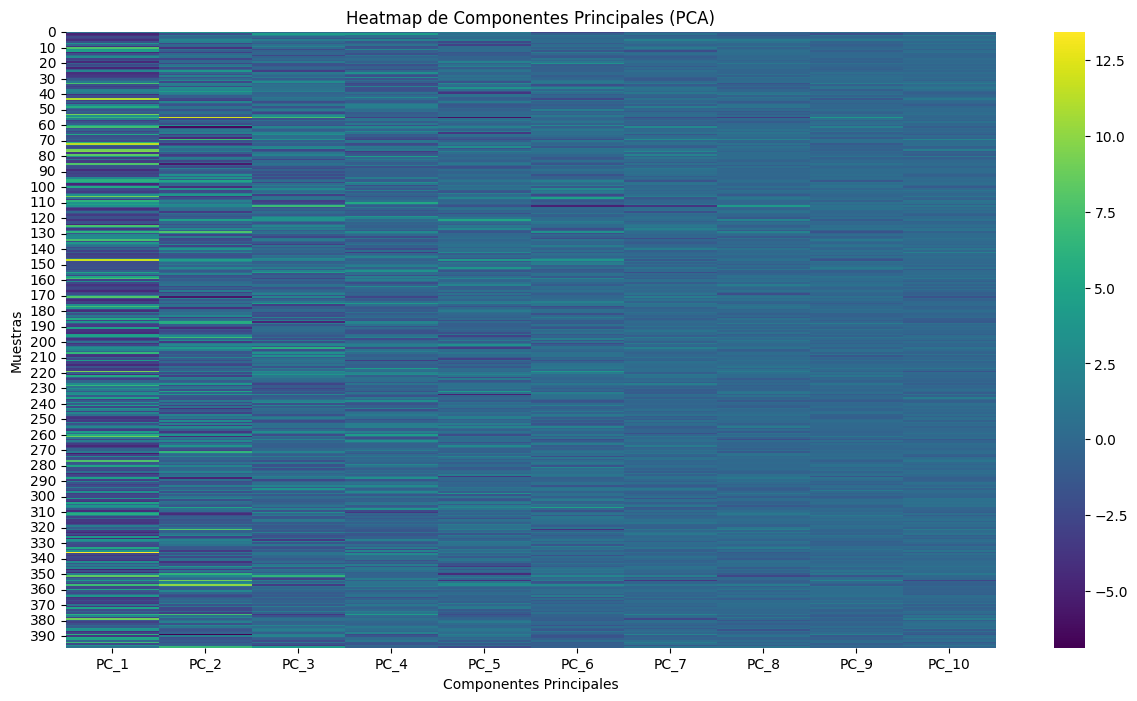

In [60]:
# Visualización de las componentes principales transformadas
plt.figure(figsize=(15, 8))
sns.heatmap(pca_df, cmap='viridis', cbar=True)
plt.title('Heatmap de Componentes Principales (PCA)')
plt.xlabel('Componentes Principales')
plt.ylabel('Muestras')
plt.show()

**Reporte de Clasificación para Modelo con PCA.**

Vamos a generar el reporte de clasificación para el modelo de Regresión Logística que utiliza 4 componentes principales, el cual mostró un buen rendimiento. Esto nos dará un desglose detallado de la precision, recall y F1-score para cada clase.

In [61]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

n_components_for_report = 4 # Elegimos 4 componentes por su buen rendimiento

# Reaplicar PCA con el número de componentes elegido
pca_report = PCA(n_components=n_components_for_report, random_state=42)
X_train_pca_report = pca_report.fit_transform(X_train_scaled)
X_test_pca_report = pca_report.transform(X_test_scaled)

# Entrenar el modelo de Regresión Logística con los datos PCA-transformados
model_pca_report = LogisticRegression(random_state=42, solver='liblinear')
model_pca_report.fit(X_train_pca_report, y_train)

# Realizar predicciones
y_pred_pca_report = model_pca_report.predict(X_test_pca_report)

print(f"### Reporte de Clasificación para Modelo con {n_components_for_report} Componentes PCA ###")
print(classification_report(y_test, y_pred_pca_report, target_names=breast_cancer.target_names))

### Reporte de Clasificación para Modelo con 4 Componentes PCA ###
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        64
      benign       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



Los resultados del modelo nos indican lo siguiente:

**Reporte de Clasificación:**
* Con 64 datos de la clase maligna (malignant), se obtiene:
    * 91% de positivos encontrados (recall).
    * 98% fueron clasificados correctamente (precision).
    * 94% es el promedio ponderado de las clases (f1-score).

* Con 107 datos de la clase benigna (benign), se obtiene:
    * 99% de positivos encontrados.
    * 95% fueron clasificados correctamente.
    * 97% es el promedio ponderado de las clases (f1-score).

El modelo tiene un accuracy de 96%.

**Tabla Comparativa de Rendimiento con PCA por Varianza Explicada.**

Vamos a consolidar los resultados en una tabla para comparar el rendimiento del modelo de Regresión Logística para diferentes niveles de varianza explicada por PCA.

In [62]:
# Encontrar el número de componentes para el 95% de la varianza si aún no está calculado
n_components_95 = find_n_components(cum_explained_variance, 0.95)

# Añadir a la lista de componentes a probar si no existe
if n_components_95 not in components_to_test:
    components_to_test.append(n_components_95)
    components_to_test = sorted(list(set(components_to_test))) # Asegurar orden y unicidad
    print(f"Se añadió {n_components_95} componentes para el 95% de la varianza explicada a la lista de evaluación.")

# Re-evaluar los modelos si es necesario para asegurar que todos los componentes estén en 'results'
for n_comp in components_to_test:
    if f'{n_comp} Components (PCA)' not in results:
        print(f"Entrenando modelo con {n_comp} componentes PCA (para el 95% de la varianza)...")
        results[f'{n_comp} Components (PCA)'] = train_and_evaluate_pca_model(n_comp)

# Preparar los datos para la tabla comparativa
data_for_table = []

# Agregar el modelo original (sin PCA)
data_for_table.append({
    'Tipo de Modelo': 'Original (No PCA)',
    '% Varianza Explicada': 'N/A',
    'Nº Componentes': X_train_scaled.shape[1],
    'Accuracy': results['Original (No PCA)']['Accuracy'],
    'F1-Score': results['Original (No PCA)']['F1-Score'],
    'AUC': results['Original (No PCA)']['AUC']
})

# Agregar los modelos con PCA
for n_comp in components_to_test:
    # Buscar la varianza explicada acumulada para este número de componentes
    # Asegurarse de que el índice no exceda el tamaño del array
    explained_var = cum_explained_variance[n_comp - 1] if n_comp <= len(cum_explained_variance) else 1.0 # O el último valor si n_comp es muy grande

    data_for_table.append({
        'Tipo de Modelo': f'{n_comp} Componentes (PCA)',
        '% Varianza Explicada': f'{explained_var:.2%}',
        'Nº Componentes': n_comp,
        'Accuracy': results[f'{n_comp} Components (PCA)']['Accuracy'],
        'F1-Score': results[f'{n_comp} Components (PCA)']['F1-Score'],
        'AUC': results[f'{n_comp} Components (PCA)']['AUC']
    })

summary_df = pd.DataFrame(data_for_table)

print("### Resumen de Rendimiento de Modelos con y sin PCA ###")
display(summary_df.sort_values(by='F1-Score', ascending=False))

Se añadió 10 componentes para el 95% de la varianza explicada a la lista de evaluación.
Entrenando modelo con 10 componentes PCA (para el 95% de la varianza)...
### Resumen de Rendimiento de Modelos con y sin PCA ###


,Tipo de Modelo,% Varianza Explicada,Nº Componentes,Accuracy,F1-Score,AUC
0,Original (No PCA),N/A,30,0.988304,0.990654,0.998102
5,10 Componentes (PCA),95.62%,10,0.970760,0.976303,0.997956
3,4 Componentes (PCA),80.28%,4,0.959064,0.968037,0.995765
4,7 Componentes (PCA),91.89%,7,0.959064,0.966825,0.995911
1,2 Componentes (PCA),64.78%,2,0.953216,0.962617,0.992261
2,3 Componentes (PCA),73.68%,3,0.912281,0.929577,0.988172


**Visualización de Componentes Principales para Clasificación.**

Vamos a generar gráficas de densidad y dispersión utilizando los componentes principales para observar cómo se separan las clases (maligno vs. benigno) en este espacio de dimensionalidad reducida.

**Gráficas de Densidad Univariable con Componentes Principales.**

Visualizaremos la distribución de las primeras componentes principales, separando por la clase objetivo.

Es importante mencionar que para las gráficas de densidad, usaremos los datos de entrenamiento transformados y su etiqueta y asi combinar X_train_pca y y_train en un DataFrame para facilitar la graficación.

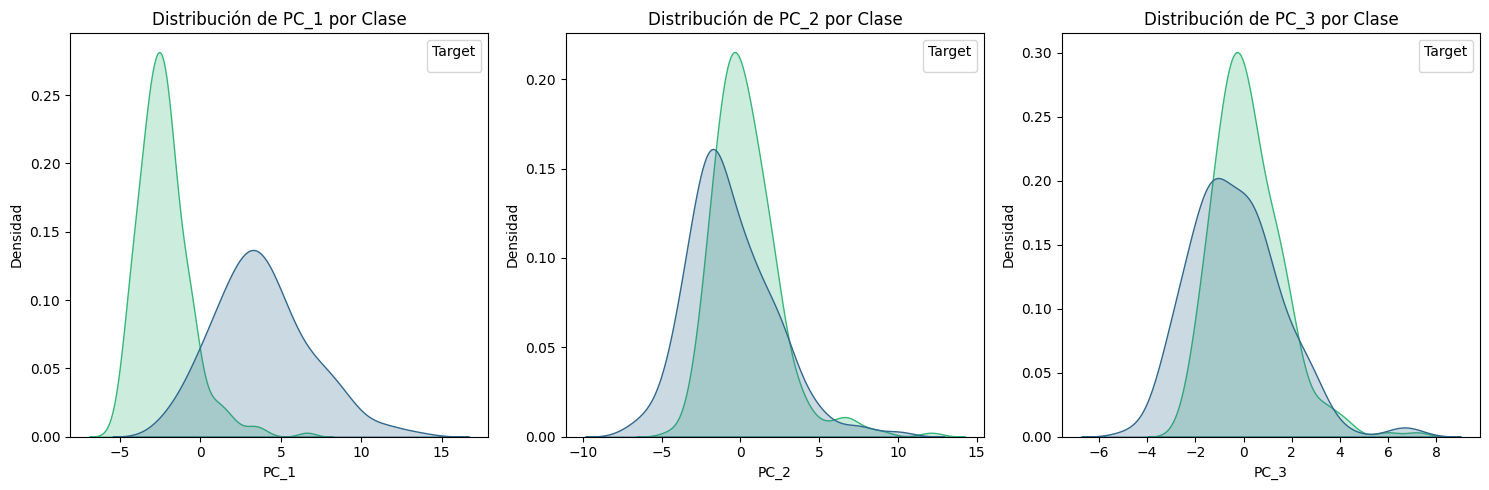

In [63]:
pca_train_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])
pca_train_df['target'] = y_train.values # Asegurarse de que el índice coincida

selected_pcs_uni = ['PC_1', 'PC_2', 'PC_3'] # Seleccionar las primeras 3 PCs

plt.figure(figsize=(15, 5))
for i, pc in enumerate(selected_pcs_uni):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=pca_train_df, x=pc, hue='target', fill=True, common_norm=False, palette='viridis')
    plt.title(f'Distribución de {pc} por Clase')
    plt.xlabel(pc)
    plt.ylabel('Densidad')
    # Personalizar las etiquetas de la leyenda
    current_handles, current_labels = plt.gca().get_legend_handles_labels()
    new_labels = [breast_cancer.target_names[int(float(label))] for label in current_labels]
    plt.gca().legend(current_handles, new_labels, title='Target')

plt.tight_layout()
plt.show()

**Gráficas de Dispersión Bivariable con Componentes Principales.**

Ahora, exploremos las relaciones entre pares de componentes principales, diferenciando por la clase objetivo.

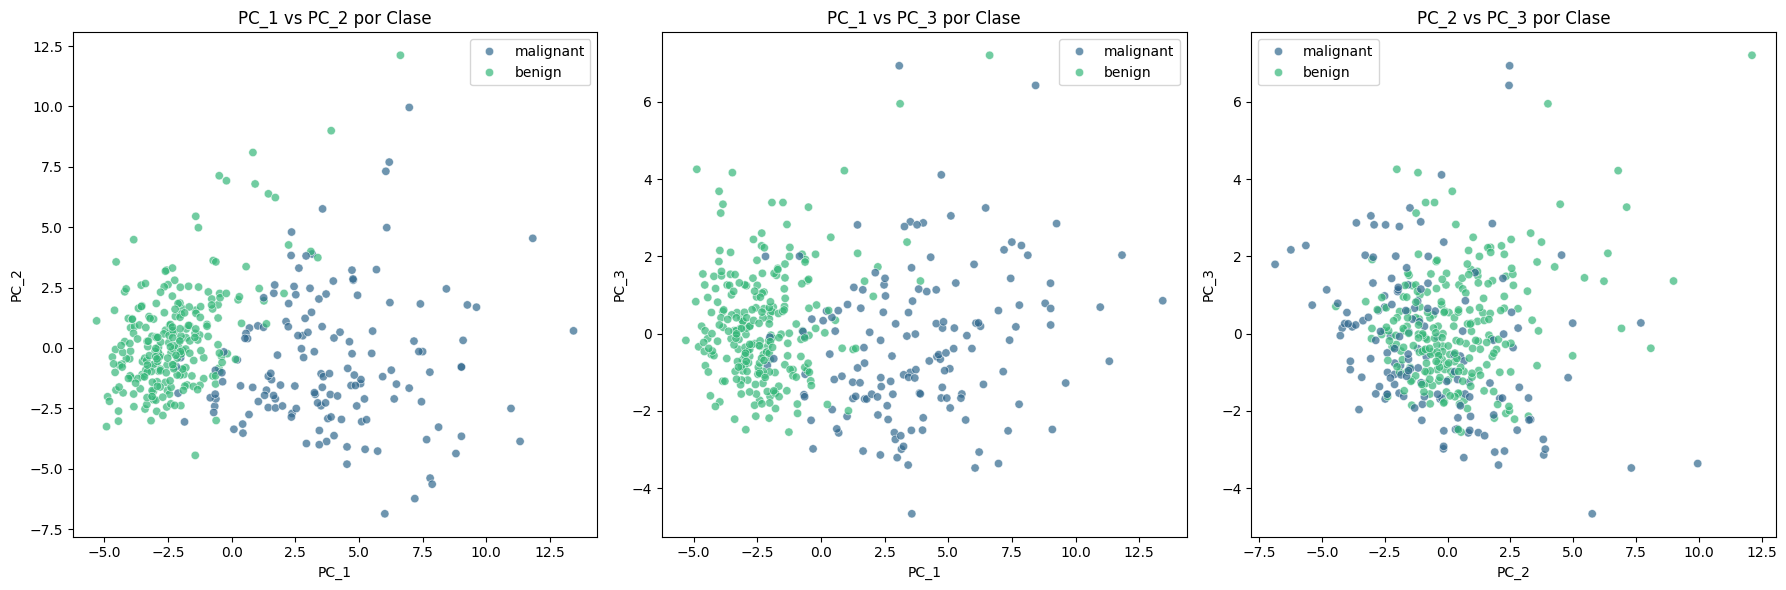

In [64]:
selected_pcs_bi = [('PC_1', 'PC_2'), ('PC_1', 'PC_3'), ('PC_2', 'PC_3')] # Seleccionar pares de PCs

plt.figure(figsize=(18, 6))
for i, (pc1, pc2) in enumerate(selected_pcs_bi):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=pc1, y=pc2, hue='target', data=pca_train_df, palette='viridis', alpha=0.7)
    plt.title(f'{pc1} vs {pc2} por Clase')
    plt.xlabel(pc1)
    plt.ylabel(pc2)
    # Personalizar las etiquetas de la leyenda
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.gca().legend(handles=handles, labels=[breast_cancer.target_names[int(float(label))] for label in labels])

plt.tight_layout()
plt.show()

**Gráficas de Densidad Univariable para Componentes Principales Específicas (PC_30).**

Para asegurar que tenemos todas las componentes (30 en este caso), re-transformamos X_train_scaled y usamos el objeto 'pca' que ya fue ajustado con n_components=None en el cell id c999288e.

X_train_pca_full contendrá todos los componentes principales.

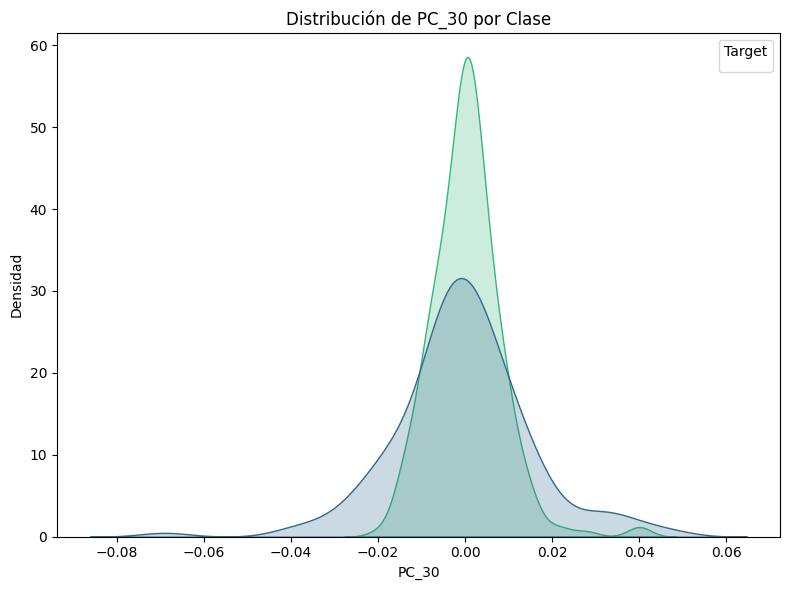

In [65]:
X_train_pca_full = pca.transform(X_train_scaled)

# Crear un DataFrame con todos los componentes principales y la variable objetivo
pca_train_df_full = pd.DataFrame(X_train_pca_full, columns=[f'PC_{i+1}' for i in range(X_train_pca_full.shape[1])])
pca_train_df_full['target'] = y_train.values

# Gráfica de densidad para PC_30
plt.figure(figsize=(8, 6))
sns.kdeplot(data=pca_train_df_full, x='PC_30', hue='target', fill=True, common_norm=False, palette='viridis')
plt.title('Distribución de PC_30 por Clase')
plt.xlabel('PC_30')
plt.ylabel('Densidad')
current_handles, current_labels = plt.gca().get_legend_handles_labels()
new_labels = [breast_cancer.target_names[int(float(label))] for label in current_labels]
plt.gca().legend(current_handles, new_labels, title='Target')
plt.tight_layout()
plt.show()

**Gráfica de Dispersión Bivariable para Componentes Principales Específicas (PC_29 vs PC_30).**

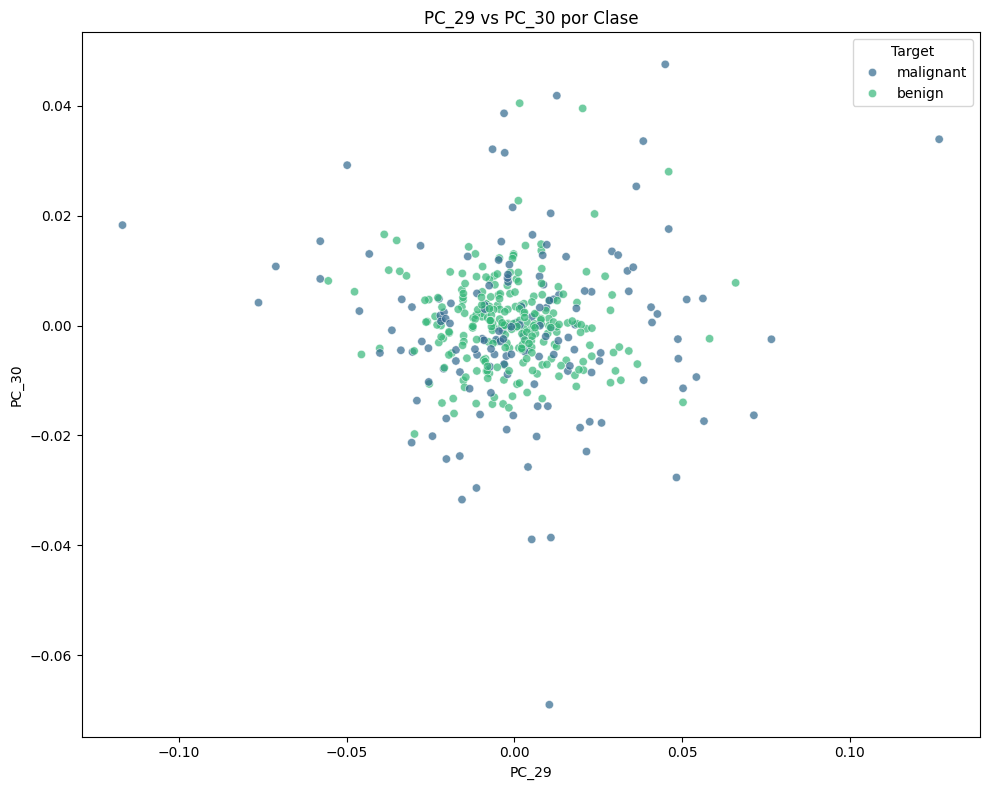

In [66]:
# Gráfica de dispersión para PC_29 vs PC_30
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC_29', y='PC_30', hue='target', data=pca_train_df_full, palette='viridis', alpha=0.7)
plt.title('PC_29 vs PC_30 por Clase')
plt.xlabel('PC_29')
plt.ylabel('PC_30')
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [breast_cancer.target_names[int(float(label))] for label in labels]
plt.gca().legend(handles=handles, labels=new_labels, title='Target')
plt.tight_layout()
plt.show()

**Análisis de Cargas (Loadings) de PCA.**

Vamos a examinar las cargas (loadings) de los componentes principales. Estas cargas nos indican la correlación entre las características originales y los componentes principales, revelando qué características tienen un mayor peso o contribución en la formación de cada componente. Esto es crucial para interpretar el significado de cada componente principal.

Cargas (Loadings) de los Componentes Principales:



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
PC_1,0.216808,0.096076,0.225343,0.219624,0.139359,0.239204,0.253645,0.259088,0.139195,0.067644,...,0.226717,0.100741,0.235089,0.223272,0.124594,0.211418,0.230362,0.250057,0.133876,0.135809
PC_2,-0.232248,-0.072765,-0.213421,-0.226519,0.182441,0.145455,0.072927,-0.032511,0.195488,0.361301,...,-0.219473,-0.060438,-0.199874,-0.216428,0.160947,0.137323,0.102415,-0.010600,0.144427,0.268941
PC_3,0.001125,0.172029,-0.001558,0.022899,-0.179138,-0.077662,-0.008103,-0.046866,-0.060871,-0.034826,...,-0.027685,0.081460,-0.030376,-0.003325,-0.292696,-0.213570,-0.147016,-0.160770,-0.249243,-0.209589
PC_4,-0.046163,0.581055,-0.046175,-0.055141,-0.066108,-0.008045,-0.018058,-0.055104,-0.051395,-0.021193,...,-0.018154,0.634966,-0.020468,-0.028426,0.088703,0.131057,0.095980,0.016817,0.072111,0.136213
PC_5,-0.033594,-0.006157,-0.033229,-0.005554,0.352671,-0.022052,-0.092346,0.043220,0.297847,0.021510,...,0.011125,0.030661,0.001896,0.039334,0.288163,-0.137445,-0.192258,-0.055120,0.233142,-0.128296


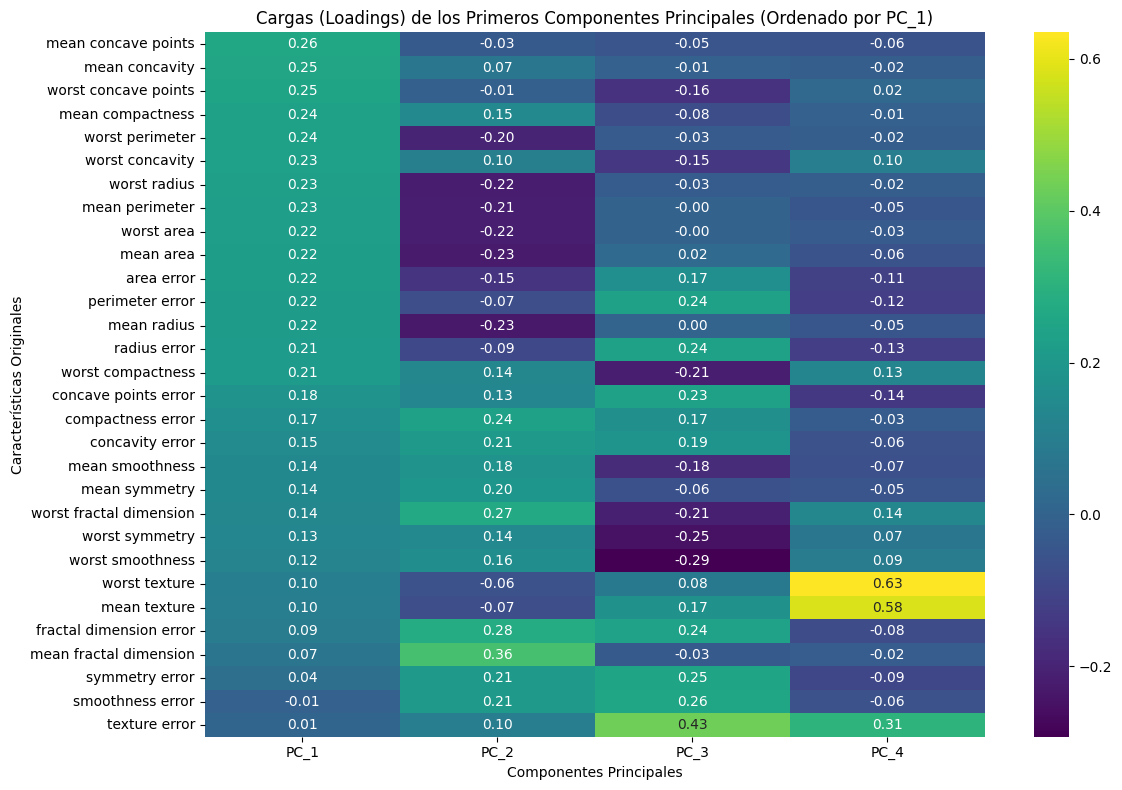

In [67]:
# Crear un DataFrame con las cargas (loadings) de PCA
# Las 'components_' del objeto PCA son las cargas (transpuestas)
loadings = pd.DataFrame(pca.components_,
                        columns=X.columns,
                        index=[f'PC_{i+1}' for i in range(pca.n_components_)])

print("Cargas (Loadings) de los Componentes Principales:\n")
display(loadings.head())

# Visualizar las cargas de los primeros componentes principales
num_components_to_plot = 4 # Por ejemplo, las primeras 4 componentes que explican una buena parte de la varianza

plt.figure(figsize=(12, 8))
# Ordenar las características por el valor absoluto de la carga en el primer componente principal (PC_1)
sorted_loadings = loadings.iloc[:num_components_to_plot].transpose().reindex(loadings.iloc[0].abs().sort_values(ascending=False).index)
sns.heatmap(sorted_loadings, cmap='viridis', annot=True, fmt=".2f")
plt.title('Cargas (Loadings) de los Primeros Componentes Principales (Ordenado por PC_1)')
plt.xlabel('Componentes Principales')
plt.ylabel('Características Originales')
plt.tight_layout()
plt.show()

**Interpretación de las Cargas.**

Observando el heatmap de cargas, podemos identificar qué características originales tienen un mayor impacto en cada componente principal:

* **PC_1**: Este componente parece estar fuertemente influenciado por características relacionadas con el tamaño y la severidad del tumor, como mean radius, mean perimeter, mean area, worst radius, worst perimeter, y worst area. Todas estas tienen cargas positivas y altas, lo que indica que PC_1 es una medida general del tamaño del tumor.

* **PC_2**: Este componente muestra altas cargas (positivas o negativas) para características como mean texture y worst texture. Esto sugiere que PC_2 podría estar capturando la variabilidad relacionada con la textura de las células.

* **PC_3** y **PC_4**: Estos componentes pueden estar capturando aspectos más sutiles de la forma y la irregularidad de las células, como mean fractal dimension, mean concavity, o mean symmetry, aunque con cargas generalmente más bajas que los primeros dos componentes.

**Extra: Aplicando PCA a una Imagen.**

Vamos a crear una imagen sintética, aplicarle PCA y luego reconstruirla para ver el efecto de la reducción de dimensionalidad.

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Crear una imagen sintética (ej. una imagen en escala de grises 100x100)
# Podemos crear un patrón simple para que sea más fácil visualizar el efecto de PCA
img_size = 100
original_image = np.zeros((img_size, img_size))

# Añadir un patrón de gradiente o alguna forma simple
for i in range(img_size):
    original_image[i, :] = np.sin(i / 10.0) * 0.5 + 0.5 # Gradiente horizontal
    original_image[:, i] += np.cos(i / 8.0) * 0.3 + 0.3 # Gradiente vertical (sumado)

# Normalizar la imagen a valores entre 0 y 1
original_image = (original_image - original_image.min()) / (original_image.max() - original_image.min())

print("Imagen sintética creada.")

Imagen sintética creada.


**Preparación de la Imagen para PCA.**

Para aplicar PCA, la imagen debe ser "aplanada" en un vector. Si tuviéramos múltiples imágenes, cada una se aplanaría en una fila de un dataset más grande. En este ejemplo, trataremos cada fila de la imagen como una 'muestra' para PCA, lo que nos permitirá ver cómo PCA reduce las características en el eje horizontal.

In [69]:
# 2. Aplanar la imagen (en este caso, cada fila es una 'muestra')
# PCA trabajará sobre las columnas (características) de esta matriz
X_image = original_image.copy()

# 3. Aplicar PCA
# Reduciremos la dimensionalidad a, digamos, 10 componentes para este ejemplo
n_components_img = 10
pca_img = PCA(n_components=n_components_img)

# Ajustar PCA y transformar los datos de la imagen
X_transformed = pca_img.fit_transform(X_image)

print(f"Dimensiones de la imagen original: {X_image.shape}")
print(f"Dimensiones de la imagen transformada (con {n_components_img} componentes): {X_transformed.shape}")

Dimensiones de la imagen original: (100, 100)
Dimensiones de la imagen transformada (con 10 componentes): (100, 10)


**Reconstrucción y Visualización.**

Ahora, reconstruiremos la imagen a partir de los componentes principales y la compararemos con la imagen original.

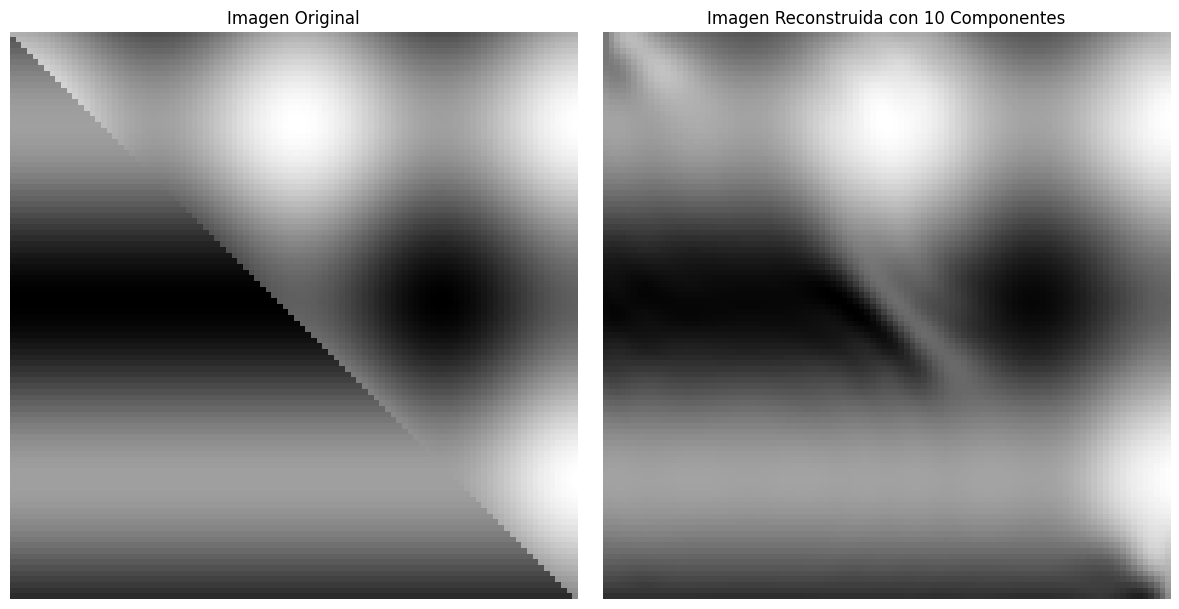

Observa cómo la imagen reconstruida captura las características principales con menos información.


In [70]:
# 4. Reconstruir la imagen
# Esto se hace invirtiendo la transformación de PCA
reconstructed_image = pca_img.inverse_transform(X_transformed)

# 5. Visualizar la imagen original y la reconstruida
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f'Imagen Reconstruida con {n_components_img} Componentes')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Observa cómo la imagen reconstruida captura las características principales con menos información.")

# Sistemas de Recomendación.

**Construcción.**

In [71]:
import pandas as pd

# 1. Definir nombres de columnas para u.data y cargar el dataset
data_cols = ['user_id', 'item_id', 'rating', 'timestamp']
df_data = pd.read_csv('/content/u.data', sep='\t', names=data_cols)

# 2. Definir nombres de columnas para u.item y cargar el dataset
# El archivo u.item contiene metadatos de las películas, incluyendo el título.
item_cols = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url',
             'unknown', 'Action', 'Adventure', 'Animation', 'Children\'s', 'Comedy',
             'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
             'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
df_item = pd.read_csv('/content/u.item', sep='|', names=item_cols, encoding='latin-1')

# 3. Fusionar df_data con df_item para asignar los nombres de las películas
# La columna 'item_id' en df_data corresponde a 'movie_id' en df_item
df_merged = pd.merge(df_data, df_item, left_on='item_id', right_on='movie_id', how='left')

# Eliminar la columna 'movie_id' ya que es redundante después de la fusión
df_merged = df_merged.drop('movie_id', axis=1)

print("Datasets u.data y u.item cargados y fusionados.")

Datasets u.data y u.item cargados y fusionados.


In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la matriz usuario-item
# Filas: user_id, Columnas: item_id, Valores: rating
# Los valores faltantes se rellenarán automáticamente con NaN por pivot_table
user_item_matrix = df_merged.pivot_table(index='user_id', columns='item_id', values='rating')

print("Matriz Usuario-Item creada. Primeras 5 filas y columnas:")
display(user_item_matrix.head())

print(f"\nNúmero total de valores NaN en la matriz: {user_item_matrix.isnull().sum().sum()}")
print(f"Porcentaje de valores NaN en la matriz: {np.mean(user_item_matrix.isnull().values):.2%}")

Matriz Usuario-Item creada. Primeras 5 filas y columnas:


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Número total de valores NaN en la matriz: 1486126
Porcentaje de valores NaN en la matriz: 93.70%


In [73]:
import random

# 1. Esconder aleatoriamente el 10% de los ratings para evaluación
# Crearemos una copia de la matriz para trabajar con ella
user_item_matrix_eval = user_item_matrix.copy()

# Obtener los índices de los ratings existentes (no NaN)
non_nan_indices = np.argwhere(~np.isnan(user_item_matrix_eval.values))

# Calcular el número de ratings a esconder (10%)
num_ratings_to_hide = int(len(non_nan_indices) * 0.10)

# Seleccionar aleatoriamente los índices a esconder
indices_to_hide = random.sample(list(non_nan_indices), num_ratings_to_hide)

# Esconder los ratings estableciéndolos en NaN
for r, c in indices_to_hide:
    user_item_matrix_eval.iloc[r, c] = np.nan

print(f"Número total de ratings en la matriz original: {user_item_matrix.count().sum()}")
print(f"Número de ratings escondidos para evaluación: {num_ratings_to_hide}")
print(f"Número de ratings restantes en user_item_matrix_eval: {user_item_matrix_eval.count().sum()}")

print("\nMatriz con ratings escondidos (primeras 5 filas):")
display(user_item_matrix_eval.head())

Número total de ratings en la matriz original: 100000
Número de ratings escondidos para evaluación: 10000
Número de ratings restantes en user_item_matrix_eval: 90000

Matriz con ratings escondidos (primeras 5 filas):


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
# 2. Centrar los ratings por usuario
# Calculamos la media de los ratings para cada usuario (ignorando NaNs)
user_ratings_mean = user_item_matrix_eval.mean(axis=1)

# Restamos la media de cada usuario a sus ratings correspondientes
# Aplicamos esta operación solo a los valores no nulos
user_item_matrix_centered = user_item_matrix_eval.apply(lambda x: x - user_ratings_mean[x.name], axis=1)

print("\nMatriz con ratings centrados por usuario (primeras 5 filas):")
display(user_item_matrix_centered.head())

print("\nEjemplo: Media de ratings para el usuario 1 antes y después de centrar:")
print(f"Media original para usuario 1: {user_item_matrix_eval.loc[1].mean():.2f}")
print(f"Media centrada para usuario 1: {user_item_matrix_centered.loc[1].mean():.2f}")


Matriz con ratings centrados por usuario (primeras 5 filas):


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.390244,-0.609756,0.390244,-0.609756,-0.609756,1.390244,0.390244,-2.609756,1.390244,-0.609756,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.267857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.180645,0.180645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Ejemplo: Media de ratings para el usuario 1 antes y después de centrar:
Media original para usuario 1: 3.61
Media centrada para usuario 1: -0.00


In [76]:
# Instalar fancyimpute si no está instalado (se asume que ya se ejecutó una vez)
# !pip install fancyimpute

from fancyimpute import SoftImpute
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Aplicando SoftImpute para la reconstrucción de la matriz...")

# Inicializar el imputador SoftImpute
# convergence_threshold: si los cambios en la matriz imputada son menores a este umbral, el algoritmo converge.
# max_iters: número máximo de iteraciones.
# SoftImpute está diseñado para completar matrices, así que lo aplicamos directamente a la matriz con NaNs (ratings escondidos).
# Aquí usamos user_item_matrix_eval que tiene los NaNs introducidos artificialmente para 'entrenamiento'.
imputer_softimpute_mc = SoftImpute(convergence_threshold=0.001, max_iters=100, shrinkage_value=None, verbose=False)

# Realizar la imputación de la matriz centrada
# SoftImpute trabaja con arrays numpy, por lo que convertimos a .values y manejamos el reindexado después
user_item_matrix_completed_values = imputer_softimpute_mc.fit_transform(user_item_matrix_eval.values)

# Convertir el resultado de nuevo a DataFrame de Pandas con los índices y columnas originales
user_item_matrix_completed = pd.DataFrame(
    user_item_matrix_completed_values,
    index=user_item_matrix_eval.index,
    columns=user_item_matrix_eval.columns
)

print("Matriz completada con SoftImpute. Primeras 5 filas y columnas reconstruidas:")
display(user_item_matrix_completed.head())

# --- Evaluación de la Reconstrucción en los Ratings Escondidos ---

# 1. Obtener los ratings originales que fueron escondidos
# Reconstruimos la lista de índices de los ratings que fueron escondidos
# Nota: 'indices_to_hide' fue generado previamente
original_hidden_ratings = []
for r, c in indices_to_hide:
    user_id = user_item_matrix.index[r]
    item_id = user_item_matrix.columns[c]
    original_hidden_ratings.append({ 'user_id': user_id, 'item_id': item_id, 'original_rating': user_item_matrix.loc[user_id, item_id] })

df_hidden_ratings = pd.DataFrame(original_hidden_ratings)

# 2. Obtener los ratings reconstruidos para estas mismas posiciones
predicted_hidden_ratings = []
for index, row in df_hidden_ratings.iterrows():
    user_id = row['user_id']
    item_id = row['item_id']
    predicted_hidden_ratings.append(user_item_matrix_completed.loc[user_id, item_id])

df_hidden_ratings['predicted_rating'] = predicted_hidden_ratings

print("\nComparación de ratings originales y predichos (primeras 5 filas de ratings escondidos):")
display(df_hidden_ratings.head())

# 3. Calcular métricas de evaluación
mae = mean_absolute_error(df_hidden_ratings['original_rating'], df_hidden_ratings['predicted_rating'])
rmse = np.sqrt(mean_squared_error(df_hidden_ratings['original_rating'], df_hidden_ratings['predicted_rating']))

print(f"\nMétricas de evaluación para la reconstrucción de ratings escondidos:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Aplicando SoftImpute para la reconstrucción de la matriz...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Matriz completada con SoftImpute. Primeras 5 filas y columnas reconstruidas:


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.000000,3.000000,4.000000,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,0.221622,0.466318,0.194320,0.129547,0.340848,0.001302,0.0,0.002603,0.0,0.649994
2,4.000000,0.969667,1.912941,1.458129,0.969378,2.349581,3.364215,1.970555,4.266248,3.012234,...,0.126602,0.174686,0.176506,0.117671,0.151466,0.039012,0.0,0.078023,0.0,0.087051
3,1.502509,0.598486,1.025513,0.964901,0.755510,0.548533,1.912485,0.986286,2.210757,0.904405,...,-0.072122,0.030916,0.301843,0.201229,0.108280,0.117618,0.0,0.235237,0.0,0.004671
4,2.518941,0.515453,1.111490,1.202367,1.019874,0.702491,2.759399,1.615367,3.303379,1.328439,...,0.022332,-0.048524,0.239629,0.159753,0.022439,0.177784,0.0,0.355569,0.0,-0.058282
5,4.000000,3.000000,1.749574,3.147246,2.664528,1.180172,4.491013,3.571144,2.467952,2.882836,...,0.080667,0.248380,0.347089,0.231393,0.268833,-0.026745,0.0,-0.053491,0.0,0.344995



Comparación de ratings originales y predichos (primeras 5 filas de ratings escondidos):


,user_id,item_id,original_rating,predicted_rating
0,189,474,5.0,4.764802
1,308,501,4.0,3.918022
2,757,98,4.0,4.386298
3,303,735,4.0,3.990161
4,447,117,4.0,3.875065



Métricas de evaluación para la reconstrucción de ratings escondidos:
Mean Absolute Error (MAE): 0.8161
Root Mean Squared Error (RMSE): 1.0476


**Tablero Interactivo de Recomendación de Peliculas.**

In [77]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Función para generar recomendaciones para un nuevo usuario ---
def generate_recommendations_for_new_user(new_user_ratings_dict, top_n_similar_users=20, top_n_recommendations=10):
    # 1. Crear una serie de pandas para los ratings del nuevo usuario
    # Asegurarse de que todos los item_ids posibles estén en el índice
    new_user_ratings_series = pd.Series(index=user_item_matrix_completed.columns, dtype=float)
    for movie_title, rating in new_user_ratings_dict.items():
        if movie_title and rating: # Asegurarse de que se haya proporcionado título de película y calificación
            item_id = df_item[df_item['movie_title'] == movie_title]['movie_id'].iloc[0]
            new_user_ratings_series.loc[item_id] = rating

    # Si el usuario no califica ninguna película, no podemos hacer recomendaciones
    if new_user_ratings_series.dropna().empty:
        return pd.DataFrame({'Mensaje': ['Por favor, califica al menos una película para obtener recomendaciones.']})

    # 2. Calcular la similitud con usuarios existentes en la matriz COMPLETADA
    # Creamos una matriz temporal incluyendo al nuevo usuario para el cálculo de similitud
    temp_completed_matrix = user_item_matrix_completed.copy()
    temp_completed_matrix.loc['new_user'] = new_user_ratings_series

    # Calcular similitud de Pearson entre el nuevo usuario y todos los demás usuarios
    user_similarity = temp_completed_matrix.T.corr(method='pearson')['new_user'].drop('new_user')
    user_similarity = user_similarity.dropna() # Eliminar similitudes NaN (e.g., si no hay películas en común)

    # Si no se encuentra ningún usuario similar, no podemos hacer recomendaciones
    if user_similarity.empty:
        return pd.DataFrame({'Mensaje': ['No se encontraron usuarios similares para generar recomendaciones.']})

    # Obtener los top N usuarios más similares
    top_similar_users = user_similarity.nlargest(top_n_similar_users).index

    # 3. Predecir ratings para el nuevo usuario basándose en los ratings predichos de usuarios similares
    predicted_ratings = pd.Series(index=user_item_matrix_completed.columns, dtype=float)

    # Obtener películas que el nuevo usuario no ha calificado (NaN en new_user_ratings_series)
    unrated_movies = new_user_ratings_series[new_user_ratings_series.isnull()].index

    for movie_id in unrated_movies:
        # Obtener los ratings de los usuarios similares para esta película desde la matriz completada
        similar_users_ratings_for_movie = user_item_matrix_completed.loc[top_similar_users, movie_id]

        # Calcular el promedio ponderado basado en la similitud
        # Asegurarse de que solo se utilicen similitudes válidas (no NaN) y que la suma de pesos sea > 0
        valid_similarities = user_similarity.loc[similar_users_ratings_for_movie.index]
        valid_similarities = valid_similarities[valid_similarities.notnull()]

        if not valid_similarities.empty and valid_similarities.sum() > 0:
            weighted_avg_rating = (similar_users_ratings_for_movie * valid_similarities).sum() / valid_similarities.sum()
            predicted_ratings.loc[movie_id] = weighted_avg_rating

    # Eliminar NaNs (películas sin predicción o ya calificadas por el nuevo usuario) y ordenar
    predicted_ratings = predicted_ratings.dropna().sort_values(ascending=False)

    # 4. Obtener las top N recomendaciones
    top_recommendations_ids = predicted_ratings.head(top_n_recommendations).index.tolist()
    top_recommendations_scores = predicted_ratings.head(top_n_recommendations).values

    # 5. Agregar información de título y género de película
    final_recommendations_data = []
    for item_id, score in zip(top_recommendations_ids, top_recommendations_scores):
        movie_info = df_item[df_item['movie_id'] == item_id].iloc[0]
        # Suponiendo que los géneros están en las columnas de df_item a partir del índice 6
        genres = [col for col in df_item.columns[6:] if movie_info[col] == 1]
        final_recommendations_data.append({
            'movie_title': movie_info['movie_title'],
            'predicted_rating': f"{score:.2f}",
            'genres': ', '.join(genres) if genres else 'N/A'
        })

    return pd.DataFrame(final_recommendations_data)

# --- Configuración de Widgets Interactivos ---

# Preparar datos de películas para los dropdowns
# Optamos por una lista más corta de películas populares o alfabética para facilitar la selección
movie_titles_sorted = df_item['movie_title'].sort_values().tolist()

# Crear widgets de selección de películas y calificación
num_input_movies = 5 # Permitir al usuario calificar hasta 5 películas
movie_dropdowns = []
rating_sliders = []

for i in range(num_input_movies):
    movie_dropdowns.append(widgets.Dropdown(
        options=[''] + movie_titles_sorted, # Opción vacía para no seleccionar
        value='',
        description=f'Película {i+1}:',
        disabled=False,
        layout=widgets.Layout(width='50%')
    ))
    rating_sliders.append(widgets.IntSlider(
        min=1,
        max=5,
        step=1,
        value=3, # Valor inicial por defecto
        description=f'Calificación {i+1}:',
        disabled=True, # Deshabilitado hasta que se seleccione una película
        layout=widgets.Layout(width='40%')
    ))

    # Observador para habilitar/deshabilitar el slider cuando se selecciona/deselecciona una película
    def create_on_movie_select_handler(slider_widget):
        def on_movie_select(change):
            slider_widget.disabled = (change.new == '')
        return on_movie_select

    movie_dropdowns[i].observe(create_on_movie_select_handler(rating_sliders[i]), names='value')

recommend_button = widgets.Button(description='Generar Recomendaciones', layout=widgets.Layout(width='auto', height='auto'))
output_area = widgets.Output()

# Mostrar los widgets
print("Por favor, selecciona y califica algunas películas para obtener recomendaciones:")
for i in range(num_input_movies):
    display(widgets.HBox([movie_dropdowns[i], rating_sliders[i]]))
display(recommend_button, output_area)

# --- Manejador del botón Generar Recomendaciones ---
def on_button_click(b):
    with output_area:
        clear_output()
        user_ratings = {}
        for i in range(num_input_movies):
            movie = movie_dropdowns[i].value
            rating = rating_sliders[i].value
            if movie and rating:
                user_ratings[movie] = rating

        if not user_ratings:
            print("Por favor, califica al menos una película para obtener recomendaciones.")
            return

        print("Generando recomendaciones...")
        recommendations_df = generate_recommendations_for_new_user(user_ratings)
        display(recommendations_df)

recommend_button.on_click(on_button_click)

Por favor, selecciona y califica algunas películas para obtener recomendaciones:


Button(description='Generar Recomendaciones', layout=Layout(height='auto', width='auto'), style=ButtonStyle())

Output()

# Código de Honor de la Universidad de Monterrey.

Doy mi palabra que he realizado esta actividad con integridad académica.